# assumpcheck example notebook

This notebook shows an initial workflow for `check_anova(...)`, `check_linear_regression(...)`, and `check_logistic_regression(...)`.


> Note
>
> The current MVP uses conservative influence heuristics. In the clean linear and logistic examples, the package still emits a mild `WARN` for influential points even when the rest of the diagnostics look reasonable.


In [1]:
%matplotlib inline

import numpy as np
import pandas as pd

from assumpcheck import (
    check_anova,
    check_linear_regression,
    check_logistic_regression,
)


## ANOVA


In [2]:
# Clean Example
# A small balanced one-way ANOVA example where all four current checks pass.

groups = np.repeat(["A", "B", "C"], 12)
base = np.array([9.80, 9.90, 10.00, 10.10, 10.20, 9.95, 10.05, 10.00, 9.85, 10.15, 9.92, 10.08])
y = np.concatenate([base, base + 0.40, base + 0.80]) + np.tile(np.linspace(-0.05, 0.05, 12), 3)

anova_clean = check_anova(
    y=y,
    groups=groups,
    design_independent=True,
    plots_on_fail=False,
    return_dict=True,
)

print()
print("Returned summary:", anova_clean["summary"])


ANOVA ASSUMPTION CHECKS
[PASS] Independence
[PASS] Normality of residuals
[PASS] Equal variance across groups
[PASS] Extreme outliers

Summary: 4 pass

Returned summary: {'pass': 4, 'fail': 0, 'warn': 0, 'info': 0}


ANOVA ASSUMPTION CHECKS
[PASS] Independence
[FAIL] Normality of residuals
[PASS] Equal variance across groups
[FAIL] Extreme outliers

Summary: 2 pass, 2 fail

Details:
- Normality of residuals [FAIL]
  Metric: Shapiro-Wilk p = < 0.001
  Threshold: p < 0.05 suggests possible non-normality. Thresholds here are heuristics, not hard laws.
  Interpretation: Residuals may depart from normality. Use the Q-Q plot alongside the p-value, especially in large samples.
  Visual: Q-Q plot of residuals
  Possible mitigation:
    - Check for outliers before changing the model.
    - Transform the response with a log, square-root, or Box-Cox transform when appropriate.
    - Consider a robust or nonparametric alternative such as Kruskal-Wallis if the problem is substantial.
- Extreme outliers [FAIL]
  Metric: Max |standardized residual| = 5.469; flagged points > 3: 1
  Threshold: Values above 2 deserve review and values above 3 are concerning.
  Interpretation: At least one observation has a standardi

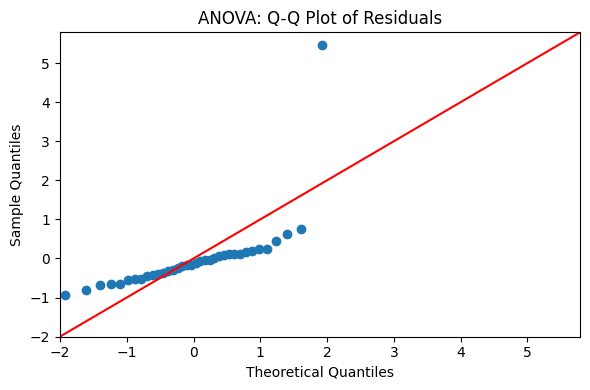

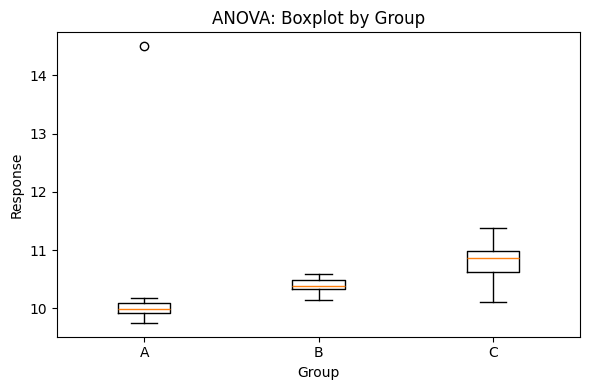

In [3]:
# Problematic Example
# A similar ANOVA setup with an injected outlier and extra spread in one group.

groups = np.repeat(["A", "B", "C"], 12)
base = np.array([9.80, 9.90, 10.00, 10.10, 10.20, 9.95, 10.05, 10.00, 9.85, 10.15, 9.92, 10.08])
y = np.concatenate([base, base + 0.40, base + 0.80]) + np.tile(np.linspace(-0.05, 0.05, 12), 3)
y[4] = 14.50
y[24:36] = y[24:36] + np.linspace(-0.45, 0.45, 12)

anova_fail = check_anova(
    y=y,
    groups=groups,
    design_independent=True,
    return_dict=True,
)

print()
print("Returned summary:", anova_fail["summary"])


ANOVA ASSUMPTION CHECKS
[PASS] Independence
[PASS] Normality of residuals
[PASS] Equal variance across groups
[PASS] Extreme outliers

Summary: 4 pass

Details:
- Independence [PASS]
  Interpretation: You indicated that the study design supports independent observations.
- Normality of residuals [PASS]
  Metric: Shapiro-Wilk p = 0.062
  Threshold: p < 0.05 suggests possible non-normality. Thresholds here are heuristics, not hard laws.
  Interpretation: Residuals do not show strong evidence against normality.
  Visual: Q-Q plot of residuals
- Equal variance across groups [PASS]
  Metric: Levene's test p = 1.000
  Threshold: p < 0.05 suggests unequal variance. Thresholds here are heuristics, not hard laws.
  Interpretation: Group spreads look reasonable for a standard ANOVA.
  Visual: Boxplot by group
- Extreme outliers [PASS]
  Metric: Max |standardized residual| = 1.947; flagged points > 3: 0
  Threshold: Values above 2 deserve review and values above 3 are concerning.
  Interpretation

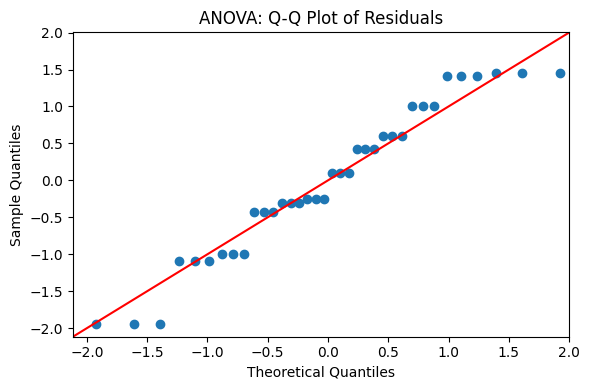

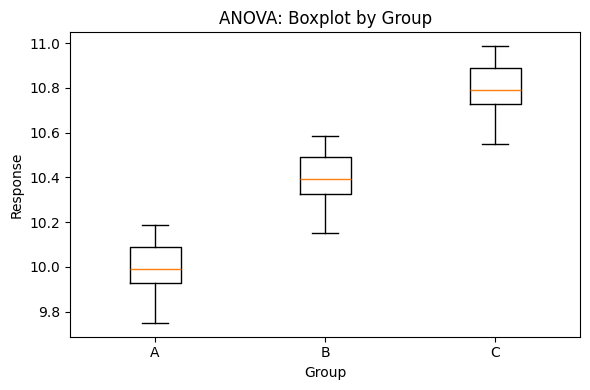

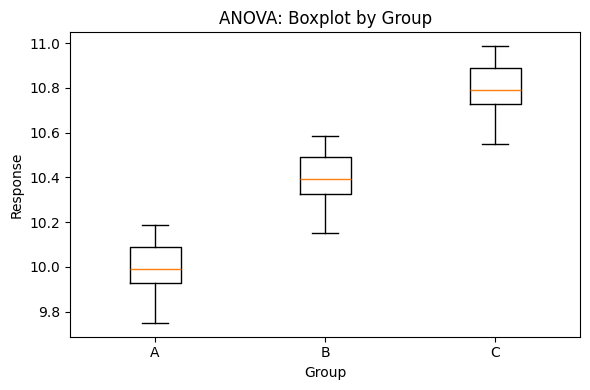

In [4]:
# Full Diagnostics
# Even when the model looks fine, you can request every available metric and plot.

groups = np.repeat(["A", "B", "C"], 12)
base = np.array([9.80, 9.90, 10.00, 10.10, 10.20, 9.95, 10.05, 10.00, 9.85, 10.15, 9.92, 10.08])
y = np.concatenate([base, base + 0.40, base + 0.80]) + np.tile(np.linspace(-0.05, 0.05, 12), 3)

anova_full = check_anova(
    y=y,
    groups=groups,
    design_independent=True,
    show_all=True,
    return_dict=True,
)

print()
print("Returned summary:", anova_full["summary"])


## Linear Regression


In [5]:
# Clean Example
# A well-behaved synthetic linear model. Under the current MVP, the influence check still gives a mild warning.

rng = np.random.default_rng(27)
X = pd.DataFrame({
    "x1": rng.normal(size=35),
    "x2": rng.normal(size=35),
})
y = 1.0 + 1.8 * X["x1"] - 0.6 * X["x2"] + rng.normal(scale=0.35, size=35)

linear_clean = check_linear_regression(
    X=X,
    y=y,
    design_independent=True,
    plots_on_fail=False,
    return_dict=True,
)

print()
print("Returned summary:", linear_clean["summary"])


LINEAR REGRESSION ASSUMPTION CHECKS
[PASS] Linearity
[PASS] Independence
[PASS] Normality of residuals
[PASS] Homoscedasticity
[PASS] Multicollinearity
[WARN] Extreme influential points

Summary: 5 pass, 1 warn

Details:
- Extreme influential points [WARN]
  Metric: Max Cook's D = 0.097; flagged points > 4/n: 0
  Threshold: Cook's D > 4/n is concerning; here 4/n = 0.114.
  Interpretation: There may be a moderately influential point worth reviewing.
  Visual: Residuals vs leverage
  Possible mitigation:
    - Verify that influential observations are valid.
    - Compare the model with and without flagged cases.
    - Use robust regression or re-specify the model if single points are driving the fit.

Returned summary: {'pass': 5, 'fail': 0, 'warn': 1, 'info': 0}


LINEAR REGRESSION ASSUMPTION CHECKS
[WARN] Linearity
[PASS] Independence
[FAIL] Normality of residuals
[PASS] Homoscedasticity
[PASS] Multicollinearity
[FAIL] Extreme influential points

Summary: 3 pass, 2 fail, 1 warn

Details:
- Linearity [WARN]
  Metric: Ramsey RESET p = < 0.001
  Threshold: Residuals should look like a random cloud; RESET p < 0.05 is a warning sign, not proof. Thresholds here are heuristics, not hard laws.
  Interpretation: There may be curvature or missing structure in the model. Use the residuals vs fitted plot as the primary diagnostic.
  Visual: Residuals vs fitted
  Possible mitigation:
    - Add polynomial terms if curvature is plausible.
    - Add interactions if the effect changes across predictors.
    - Transform predictors or the response if the scale is causing the pattern.
    - Use a more flexible model form if the relationship is clearly nonlinear.
- Normality of residuals [FAIL]
  Metric: Shapiro-Wilk p = < 0.001
  Threshold: p < 0.05 suggests possi

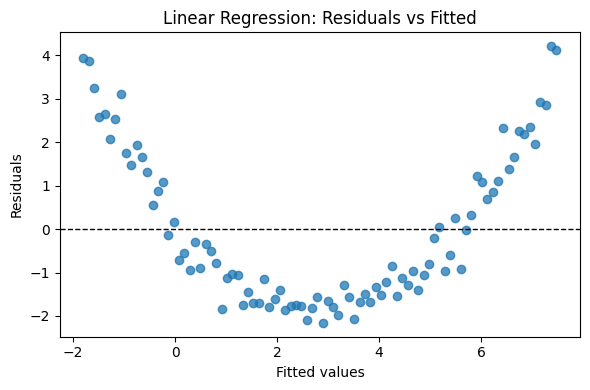

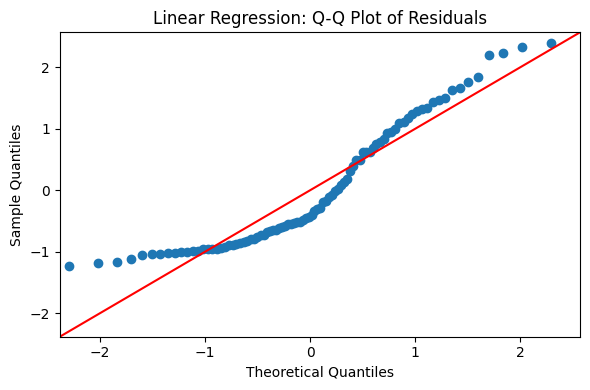

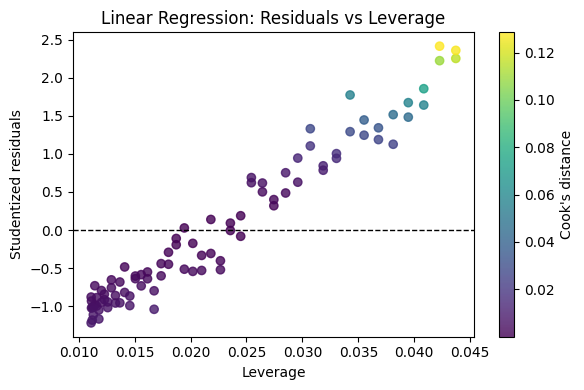

In [6]:
# Problematic Example
# A nonlinear signal with non-constant variance to trigger multiple diagnostics.

rng = np.random.default_rng(7)
x = np.linspace(-2.5, 2.5, 90)
X = pd.DataFrame({"x1": x})
noise = rng.normal(scale=0.20 + 0.20 * np.abs(x), size=x.size)
y = 1.0 + 1.8 * x + 0.9 * x**2 + noise

linear_fail = check_linear_regression(
    X=X,
    y=y,
    design_independent=True,
    return_dict=True,
)

print()
print("Returned summary:", linear_fail["summary"])


LINEAR REGRESSION ASSUMPTION CHECKS
[PASS] Linearity
[PASS] Independence
[PASS] Normality of residuals
[PASS] Homoscedasticity
[PASS] Multicollinearity
[WARN] Extreme influential points

Summary: 5 pass, 1 warn

Details:
- Linearity [PASS]
  Metric: Ramsey RESET p = 0.230
  Threshold: Residuals should look like a random cloud; RESET p < 0.05 is a warning sign, not proof. Thresholds here are heuristics, not hard laws.
  Interpretation: Residual diagnostics do not show strong evidence of nonlinearity.
  Visual: Residuals vs fitted
- Independence [PASS]
  Interpretation: You indicated that the study design supports independent errors.
- Normality of residuals [PASS]
  Metric: Shapiro-Wilk p = 0.431
  Threshold: p < 0.05 suggests possible non-normality. Thresholds here are heuristics, not hard laws.
  Interpretation: Residuals do not show strong evidence against normality.
  Visual: Q-Q plot of residuals
- Homoscedasticity [PASS]
  Metric: Breusch-Pagan p = 0.472
  Threshold: p < 0.05 sugg

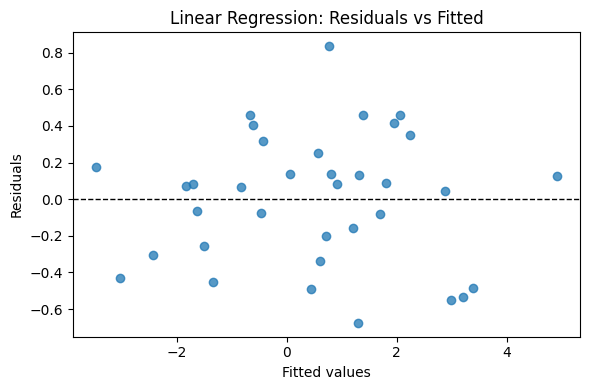

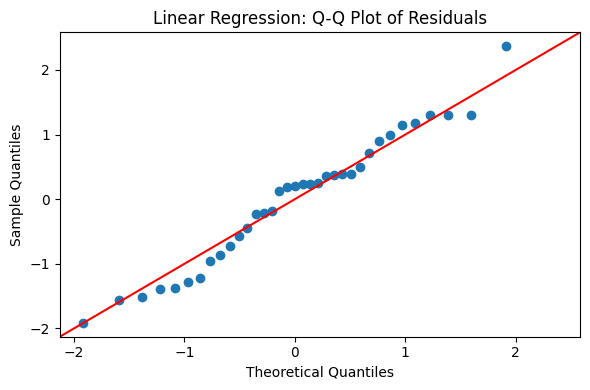

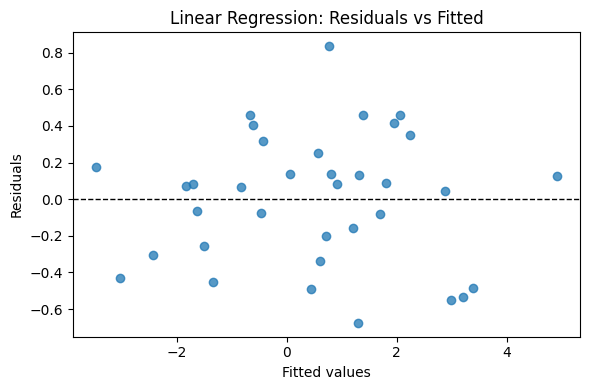

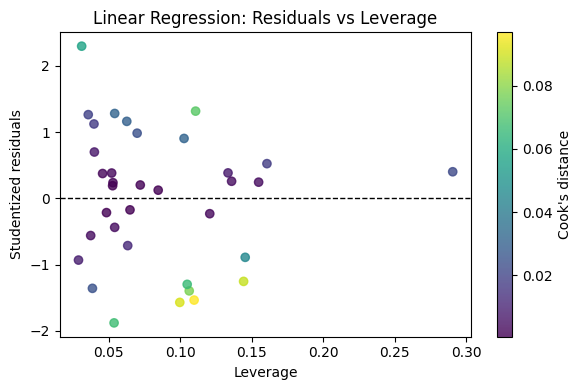

In [7]:
# Full Diagnostics
# Request all detail and all plots for the cleaner linear example.

rng = np.random.default_rng(27)
X = pd.DataFrame({
    "x1": rng.normal(size=35),
    "x2": rng.normal(size=35),
})
y = 1.0 + 1.8 * X["x1"] - 0.6 * X["x2"] + rng.normal(scale=0.35, size=35)

linear_full = check_linear_regression(
    X=X,
    y=y,
    design_independent=True,
    show_all=True,
    return_dict=True,
)

print()
print("Returned summary:", linear_full["summary"])


## Logistic Regression


In [8]:
# Clean Example
# A stable logistic model. The current influence heuristic still tends to emit a mild warning.

rng = np.random.default_rng(44)
X = pd.DataFrame({
    "x1": rng.normal(size=45),
    "x2": rng.normal(size=45),
})
logits = -0.2 + 0.9 * X["x1"] - 0.5 * X["x2"]
p = 1 / (1 + np.exp(-logits))
y = rng.binomial(1, p)

logistic_clean = check_logistic_regression(
    X=X,
    y=y,
    design_independent=True,
    plots_on_fail=False,
    return_dict=True,
)

print()
print("Returned summary:", logistic_clean["summary"])
print("Model fit metric:", logistic_clean["diagnostics"][0]["metric"])


LOGISTIC REGRESSION ASSUMPTION CHECKS
[PASS] Linearity in the log-odds
[PASS] Independence
[PASS] Multicollinearity
[WARN] Extreme influential points
[PASS] Adequate sample / no separation

Summary: 4 pass, 1 warn

Details:
- Extreme influential points [WARN]
  Metric: Max Cook's D = 0.080; flagged points > 4/n: 0
  Threshold: Cook's D > 4/n is concerning; here 4/n = 0.089.
  Interpretation: There may be a moderately influential case worth checking.
  Possible mitigation:
    - Verify unusual cases before making changes.
    - Compare the fit with and without flagged cases.
    - Re-specify the model if influential cases reveal a structural issue.

Returned summary: {'pass': 4, 'fail': 0, 'warn': 1, 'info': 0}
Model fit metric: AUC = 0.620


In [9]:
# Problematic Example
# A near-perfect separation setup that should clearly fail the stability check.

x = np.linspace(-2.5, 2.5, 80)
X = pd.DataFrame({
    "x1": x,
    "x2": np.sin(x),
})
y = (x > 0.0).astype(int)

logistic_fail = check_logistic_regression(
    X=X,
    y=y,
    design_independent=True,
    return_dict=True,
)

print()
print("Returned summary:", logistic_fail["summary"])


LOGISTIC REGRESSION ASSUMPTION CHECKS
[INFO] Linearity in the log-odds
[PASS] Independence
[WARN] Multicollinearity
[FAIL] Extreme influential points
[FAIL] Adequate sample / no separation

Summary: 1 pass, 2 fail, 1 warn, 1 info

Details:
- Multicollinearity [WARN]
  Metric: Max VIF = 7.360 (x2)
  Threshold: VIF > 5 deserves caution and VIF > 10 is a serious concern.
  Interpretation: Predictor 'x2' shows noticeable collinearity.
  Possible mitigation:
    - Remove or combine redundant predictors.
    - Use regularization if stable prediction matters more than coefficient interpretation.
- Extreme influential points [FAIL]
  Metric: Max Cook's D = 1479330280139.682; flagged points > 4/n: 80
  Threshold: Cook's D > 4/n is concerning; here 4/n = 0.050.
  Interpretation: At least one case exceeds the common Cook's distance concern threshold.
  Possible mitigation:
    - Verify unusual cases before making changes.
    - Compare the fit with and without flagged cases.
    - Re-specify the 

LOGISTIC REGRESSION ASSUMPTION CHECKS
[PASS] Linearity in the log-odds
[PASS] Independence
[PASS] Multicollinearity
[WARN] Extreme influential points
[PASS] Adequate sample / no separation

Summary: 4 pass, 1 warn

Details:
- Linearity in the log-odds [PASS]
  Metric: Worst Box-Tidwell p = 0.564 (x2)
  Threshold: p < 0.05 suggests nonlinearity in the log-odds. Thresholds here are heuristics, not hard laws.
  Interpretation: Continuous predictors do not show strong evidence against linearity in the log-odds.
  Visual: Binned logit plot for x2
- Independence [PASS]
  Interpretation: You indicated that the study design supports independent observations.
- Multicollinearity [PASS]
  Metric: Max VIF = 1.051 (x1)
  Threshold: VIF > 5 deserves caution and VIF > 10 is a serious concern.
  Interpretation: Predictor VIF values are in a commonly acceptable range.
- Extreme influential points [WARN]
  Metric: Max Cook's D = 0.080; flagged points > 4/n: 0
  Threshold: Cook's D > 4/n is concerning; 

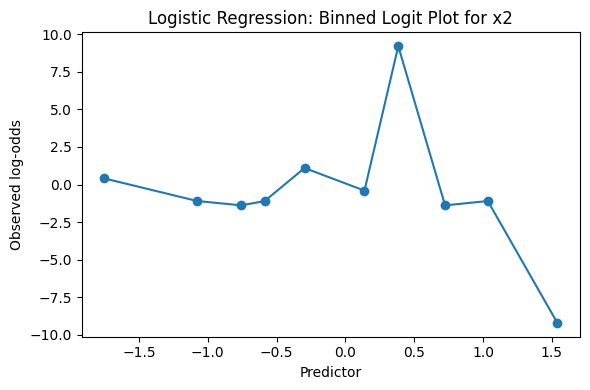

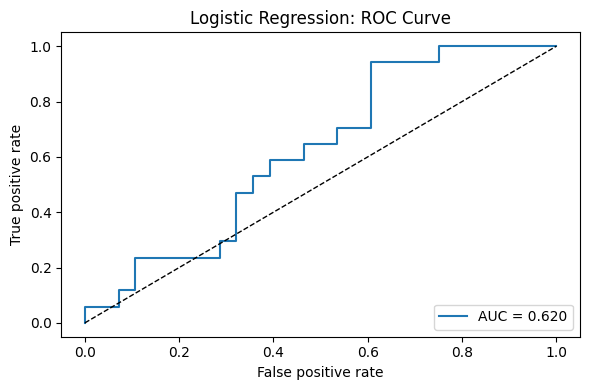

In [10]:
# Full Diagnostics
# Request the full logistic diagnostic view, including the ROC curve.

rng = np.random.default_rng(44)
X = pd.DataFrame({
    "x1": rng.normal(size=45),
    "x2": rng.normal(size=45),
})
logits = -0.2 + 0.9 * X["x1"] - 0.5 * X["x2"]
p = 1 / (1 + np.exp(-logits))
y = rng.binomial(1, p)

logistic_full = check_logistic_regression(
    X=X,
    y=y,
    design_independent=True,
    show_all=True,
    return_dict=True,
)

print()
print("Returned summary:", logistic_full["summary"])
print("Model fit metric:", logistic_full["diagnostics"][0]["metric"])
